## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

## Load data

In [4]:
df = pd.read_csv(r"C:\Users\start\Downloads\archive\car data.csv")
print("Shape:", df.shape)
df.head()

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
print("Missing values:\n", df.isna().sum())

Missing values:
 Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


## Clean data

In [7]:
n_dup = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {n_dup} duplicate rows -> {df.shape[0]} rows left")

Removed 2 duplicate rows -> 299 rows left


## Feature engineering

In [9]:
CURRENT_YEAR = 2020  # dataset's latest model year is 2018; fixed reference for reproducibility
df["Car_Age"] = CURRENT_YEAR - df["Year"]
df["Brand"] = df["Car_Name"].str.split().str[0].str.lower()      # first word = brand/model family
df["Kms_per_Year"] = df["Driven_kms"] / df["Car_Age"].clip(lower=1)
df["Log_Driven_kms"] = np.log1p(df["Driven_kms"])                  # tame the 500,000 km outlier

# "Brand goodwill" is computed on TRAIN only (avoids leakage) -> done after the split below.
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand,Kms_per_Year,Log_Driven_kms
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,6,ritz,4500.000000,10.203629
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,7,sx4,6142.857143,10.668979
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,3,ciaz,2300.000000,8.839422
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,9,wagon,577.777778,8.556606
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,6,swift,7075.000000,10.656106


## Exploratory data analysis (EDA)

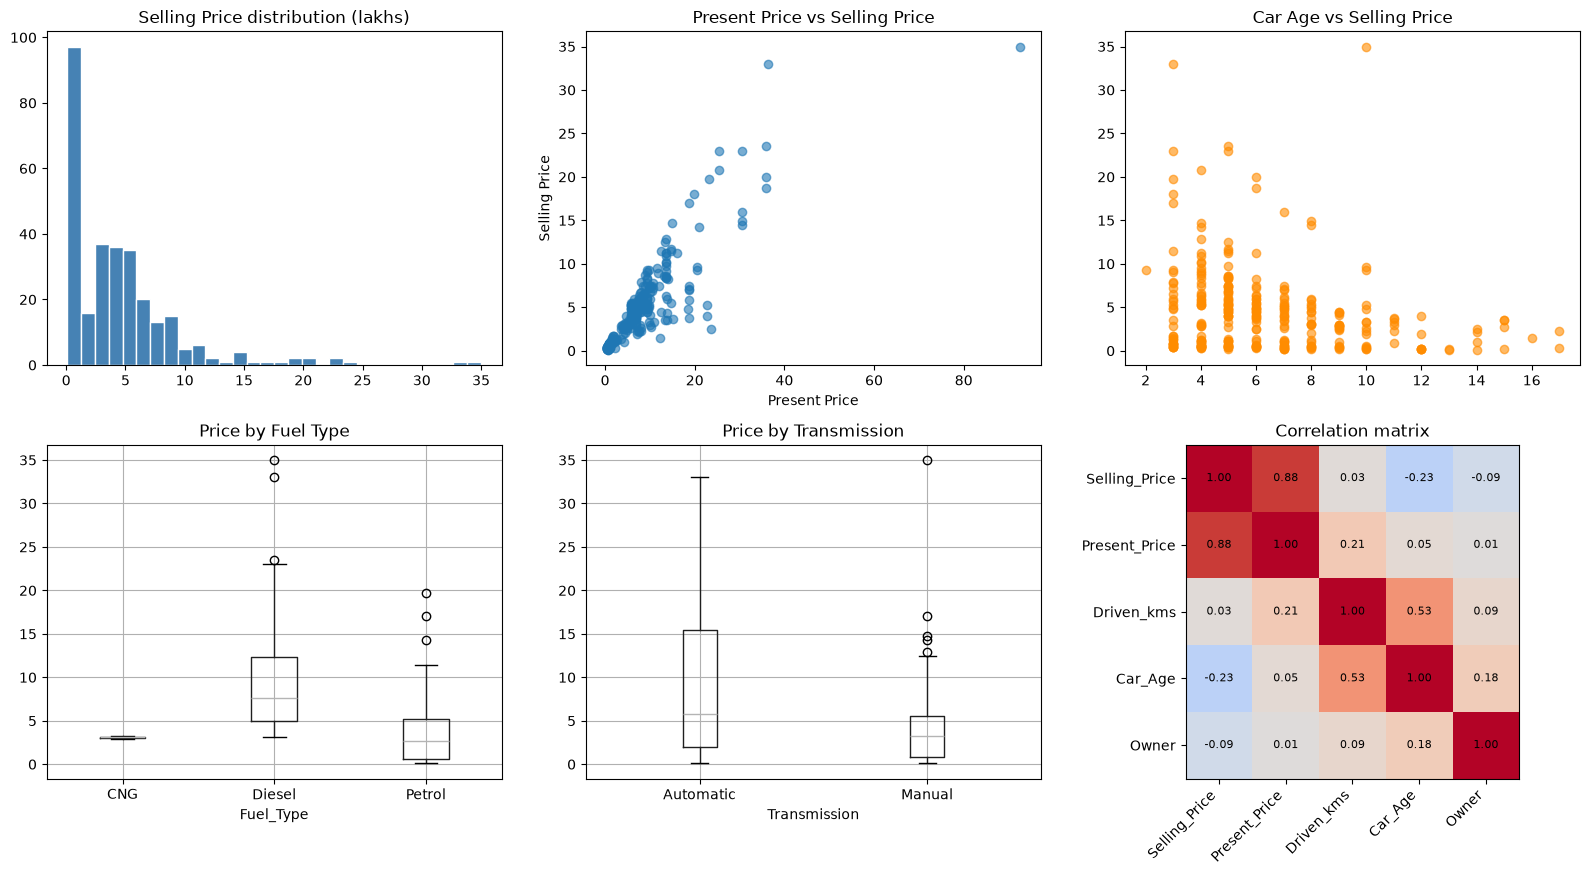

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes[0, 0].hist(df["Selling_Price"], bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Selling Price distribution (lakhs)")
axes[0, 1].scatter(df["Present_Price"], df["Selling_Price"], alpha=0.6)
axes[0, 1].set_title("Present Price vs Selling Price")
axes[0, 1].set_xlabel("Present Price"); axes[0, 1].set_ylabel("Selling Price")
axes[0, 2].scatter(df["Car_Age"], df["Selling_Price"], alpha=0.6, color="darkorange")
axes[0, 2].set_title("Car Age vs Selling Price")
df.boxplot(column="Selling_Price", by="Fuel_Type", ax=axes[1, 0]); axes[1, 0].set_title("Price by Fuel Type")
df.boxplot(column="Selling_Price", by="Transmission", ax=axes[1, 1]); axes[1, 1].set_title("Price by Transmission")

num_cols_corr = ["Selling_Price", "Present_Price", "Driven_kms", "Car_Age", "Owner"]
corr = df[num_cols_corr].corr()
im = axes[1, 2].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1, 2].set_xticks(range(len(corr))); axes[1, 2].set_xticklabels(corr.columns, rotation=45, ha="right")
axes[1, 2].set_yticks(range(len(corr))); axes[1, 2].set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        axes[1, 2].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
axes[1, 2].set_title("Correlation matrix")
plt.suptitle("")
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=130)
plt.show()

## Train / test split

In [13]:
y = df["Selling_Price"]
X = df.drop(columns=["Selling_Price", "Car_Name", "Year", "Driven_kms"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (239, 9) | Test: (60, 9)


## Brand goodwill (learned from training data only)
Average `Selling_Price / Present_Price` per brand, shrunk toward the global mean for small brands.

In [15]:
ratio = (y_train / X_train["Present_Price"]).groupby(X_train["Brand"]).agg(["mean", "count"])
global_ratio = (y_train / X_train["Present_Price"]).mean()
SMOOTH = 5  # shrink small brands toward the global mean
ratio["goodwill"] = (ratio["mean"] * ratio["count"] + global_ratio * SMOOTH) / (ratio["count"] + SMOOTH)
goodwill_map = ratio["goodwill"].to_dict()

for part in (X_train, X_test):
    part["Brand_Goodwill"] = part["Brand"].map(goodwill_map).fillna(global_ratio)
X_train = X_train.drop(columns=["Brand"])
X_test = X_test.drop(columns=["Brand"])
X_train.head()

,Present_Price,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Kms_per_Year,Log_Driven_kms,Brand_Goodwill
6,8.12,Petrol,Dealer,Manual,0,5,3759.200000,9.841453,0.718448
183,0.58,Petrol,Individual,Automatic,0,12,158.333333,7.550135,0.604993
185,0.51,Petrol,Individual,Manual,0,7,4571.428571,10.373522,0.638872
146,0.94,Petrol,Individual,Manual,0,10,4500.000000,10.714440,0.588499
30,4.89,Petrol,Dealer,Manual,0,9,6022.222222,10.900455,0.599647


## Preprocessing pipeline

In [17]:
cat_features = ["Fuel_Type", "Selling_type", "Transmission"]
num_features = [c for c in X_train.columns if c not in cat_features]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
])

## Custom wrapper: `RatioRegressor`
Fits the base model on `log(Selling / Present)` and predicts `Selling = Present * exp(pred)`.

In [19]:
class RatioRegressor(BaseEstimator, RegressorMixin):
    """Fits base model on log(Selling/Present); predicts Selling = Present * exp(pred)."""
    def __init__(self, base=None):
        self.base = base
    def fit(self, X, y):
        self.base_ = clone(self.base)
        self.base_.fit(X, np.log(y / X["Present_Price"]))
        return self
    def predict(self, X):
        return np.exp(self.base_.predict(X)) * X["Present_Price"].values

## Train and compare models

In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for name, model in models.items():
    pipe = RatioRegressor(Pipeline([("prep", preprocess), ("model", model)]))
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=kf, scoring="r2")
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        "Model": name,
        "CV R2 (mean)": cv_r2.mean(),
        "Test R2": r2_score(y_test, pred),
        "Test MAE": mean_absolute_error(y_test, pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
    })

results = pd.DataFrame(rows).sort_values("Test R2", ascending=False).reset_index(drop=True)
results.to_csv("model_comparison.csv", index=False)
print("=== Model comparison ===")
results.round(3)

=== Model comparison ===


,Model,CV R2 (mean),Test R2,Test MAE,Test RMSE
0,Gradient Boosting,0.968,0.974,0.537,0.811
1,Linear Regression,0.965,0.970,0.574,0.876
2,Ridge,0.966,0.970,0.582,0.882
3,Random Forest,0.972,0.961,0.632,1.009


## Hyperparameter tuning (Gradient Boosting)

In [23]:
param_grid = {
    "base__model__n_estimators": [200, 400],
    "base__model__max_depth": [2, 3, 4],
    "base__model__learning_rate": [0.03, 0.05, 0.1],
    "base__model__subsample": [0.8, 1.0],
}
search = GridSearchCV(
    RatioRegressor(Pipeline([("prep", preprocess), ("model", GradientBoostingRegressor(random_state=42))])),
    param_grid, cv=kf, scoring="r2", n_jobs=-1,
)
search.fit(X_train, y_train)
best = search.best_estimator_
print("Best params:", search.best_params_)

Best params: {'base__model__learning_rate': 0.05, 'base__model__max_depth': 3, 'base__model__n_estimators': 200, 'base__model__subsample': 0.8}


## Final evaluation

In [25]:
pred = best.predict(X_test)
print("=== Tuned Gradient Boosting (test set) ===")
print(f"R2   : {r2_score(y_test, pred):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, pred):.4f} lakhs")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, pred)):.4f} lakhs")

=== Tuned Gradient Boosting (test set) ===
R2   : 0.9721
MAE  : 0.5564 lakhs
RMSE : 0.8476 lakhs


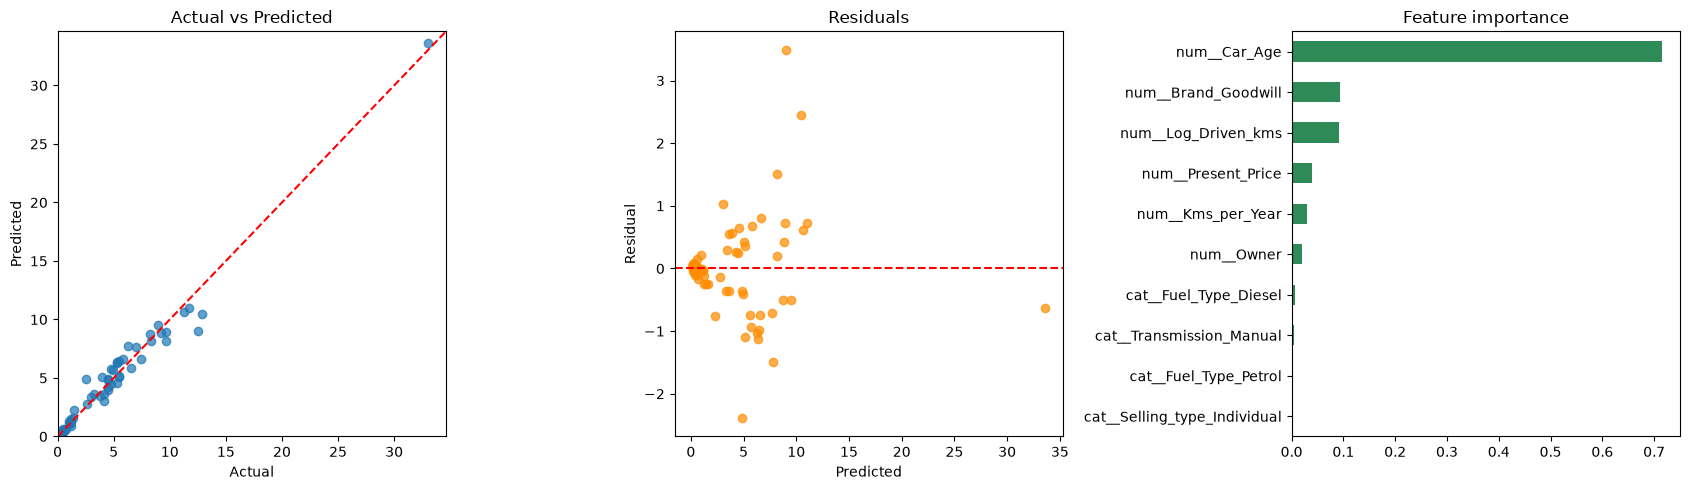

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Actual vs Predicted
axes[0].scatter(y_test, pred, alpha=0.7)
lims = [0, max(y_test.max(), pred.max()) + 1]
axes[0].plot(lims, lims, "r--"); axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted"); axes[0].set_title("Actual vs Predicted")

# Residuals
resid = y_test - pred
axes[1].scatter(pred, resid, alpha=0.7, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals")

# Feature importance
feat_names = best.base_.named_steps["prep"].get_feature_names_out()
imp = pd.Series(best.base_.named_steps["model"].feature_importances_, index=feat_names).sort_values()
imp.plot.barh(ax=axes[2], color="seagreen"); axes[2].set_title("Feature importance")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=130)
plt.show()

In [27]:
print("Top features:")
imp.sort_values(ascending=False).head(6).round(3)

Top features:


num__Car_Age           0.714
num__Brand_Goodwill    0.093
num__Log_Driven_kms    0.091
num__Present_Price     0.039
num__Kms_per_Year      0.030
num__Owner             0.020
dtype: float64

## Save the model

In [29]:
joblib.dump({"pipeline": best, "goodwill_map": goodwill_map, "global_ratio": global_ratio},
            "car_price_model.joblib")
print("Model saved to car_price_model.joblib")

Model saved to car_price_model.joblib
